In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

"I can't believe it, IMDb really does have every TV show known to man! I have not seen this show in over 20 years. I only remember two episodes, and I barely remember those. I remember that Tony may not been on from the start, because one of the episodes I remember is the one in which everybody trying to get Tony to join, but he rejects them, but typically at the end of the show he becomes a member of Power House, with everybody cheering.<br /><br />The other one I remember is the one where Lolo for some reason pretends to be dead,(complete with funeral and mourners). I don't remember why he plays dead, or how the show ends.<br /><br />This is one of those shows that I convinced myself that I must have dreamed up since no one else had ever heard of it."

In [5]:
print(preprocess(df.iloc[random_num]['review']))

believe imdb really every show known man seen show year remember two episode barely remember remember tony may start one episode remember one everybody trying get tony join reject typically end show becomes member power house everybody cheering one remember one lolo reason pretend dead complete funeral mourner remember play dead show end one show convinced must dreamed since one else ever heard


In [6]:
df['review'] = df['review'].apply(preprocess)

In [7]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [8]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [10]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [12]:
max_len = 5

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [13]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(2, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(4, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 4)           │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 5, 4)           │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 2)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,073 (312.79 KB)

 Trainable params: 80,073 (312.79 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [ ]:
"""lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)"""

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6956 - loss: 0.5700 - val_accuracy: 0.7048 - val_loss: 0.5737 - learning_rate: 2.5000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6989 - loss: 0.5652 - val_accuracy: 0.7010 - val_loss: 0.5747 - learning_rate: 2.5000e-04


In [ ]:
#lstm_model.save_weights("lstm_modelo_leve.weights.h5")

In [39]:

lstm_model.load_weights("lstm_modelo_leve.weights.h5")

In [18]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [40]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - accuracy: 0.7016 - loss: 0.5742
Test Accuracy: 0.7016000151634216


#### Acurácia de 0.80119

# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


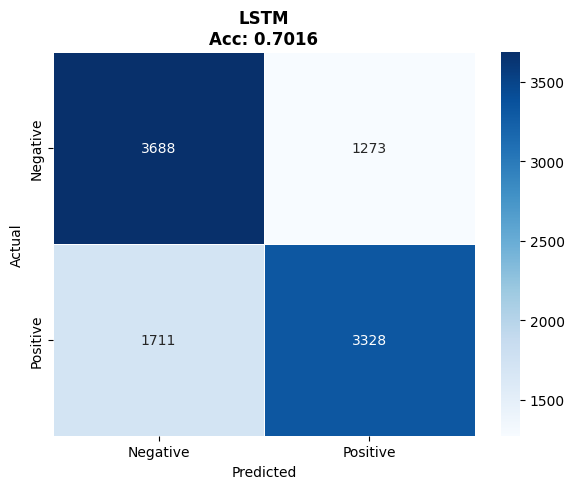

In [20]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [21]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.68      0.74      0.71      4961
    Positive       0.72      0.66      0.69      5039

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



# Teste de Outputs


In [22]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[0].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplest_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
Outputs salvos em layer_outputs_simplest_model.txt


In [36]:
lstm_model.get_state_tree()

{'trainable_variables': {'sequential': {'embedding': {'embeddings': <tf.Variable 'sequential/embedding/embeddings:0' shape=(20000, 4) dtype=float32, numpy=
    array([[ 1.63638193e-04,  2.11672205e-02,  1.22424457e-02,
            -6.96836412e-02],
           [-1.41847832e-02,  3.18138581e-03, -1.55192846e-03,
            -1.13994144e-02],
           [-6.70563150e-03,  1.97076984e-02, -1.74608156e-02,
            -1.70068331e-02],
           [ 5.69056347e-03, -2.04041158e-03,  7.32305227e-03,
             4.86960774e-03],
           [ 1.08144956e-03, -5.61760273e-03,  6.84820209e-03,
             5.75519539e-03],
           [-7.10618729e-03,  7.77668040e-03,  8.34169696e-05,
             2.52956338e-03],
           [-1.37342345e-02, -1.22521049e-03,  1.38516920e-02,
             1.73882023e-02],
           [-1.75128467e-02,  2.20937952e-02, -1.51910977e-02,
            -1.17475707e-02],
           [ 6.65726420e-03, -8.24336801e-03,  2.71996167e-02,
             2.53998563e-02],
       

In [23]:
from functions import *

# Exportação de Pesos

In [24]:
export_weights(lstm_model, mode='lstm', output_file="../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/weights.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_input[0][0] = 0.560012
  addr=0x08001 Wx_input[0][1] = -0.147327
  addr=0x08080 Wx_input[1][0] = -0.119848
  addr=0x08081 Wx_input[1][1] = 0.184697
  addr=0x08040 Wh_input[0][0] = 0.352466
  addr=0x08041 Wh_input[0][1] = -0.354244
  addr=0x080C0 Wh_input[1][0] = -0.473668
  addr=0x080C1 Wh_input[1][1] = -1.306123
  addr=0x18000 bias_input[0] = 0.638674
  addr=0x18080 bias_input[1] = 0.570141
  addr=0x0A000 Wx_forget[0][0] = 0.184087
  addr=0x0A001 Wx_forget[0][1] = -0.776087
  addr=0x0A080 Wx_forget[1][0] = 1.166812
  addr=0x0A081 Wx_forget[1][1] = -0.396893
  addr=0x0A040 Wh_forget[0][0] = 0.310294
  addr=0x0A041 Wh_forget[0][1] = -0.412904
  addr=0x0A0C0 Wh_forget[1][0] = 0.041116
  addr=0x0A0C1 Wh_forget[1][1] = -0.144180
  addr=0x1A000 bias_forget[0] = 0.955248
  addr=0x1A080 bias_forget[1] = 1.335935
  addr=0x0C000 Wx_candidate[0][0] = -0.708347
  addr=0

# Teste Global

In [25]:
FRAC = 24
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q24(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [26]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q24 = float_to_q24(valor)  # sua função original
            mem[addr] = valor_q24
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q24(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [27]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
#total = len(y_pred_lstm)
total = 50

valores_out_embbeding = []
valores_out_lstm = []
valores_out_relu = []
valores_out_sigmoid = []

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_{i}.mem")

    valores_out_embbeding += outputs[0].reshape(-1).tolist()
    valores_out_lstm += outputs[2].reshape(-1).tolist()
    valores_out_relu += outputs[4].reshape(-1).tolist()
    valores_out_sigmoid += outputs[6].reshape(-1).tolist()

    print(f"{i} de {total}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_0.mem
0 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_1.mem
1 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_2.mem
2 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_3.mem
3 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_4.mem
4 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Arquivo salvo: ../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_5.mem
5 de 50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

In [41]:
out_verilog=pd.read_csv("resultados_lstm.txt",skiprows=3,header=None,sep=" ")[12]
out_verilog 

0     0.426999
1     0.253196
2    -0.106051
3    -0.033208
4    -0.295246
        ...   
95   -0.126627
96   -0.230331
97   -0.193621
98    0.143159
99    0.091574
Name: 12, Length: 100, dtype: float64

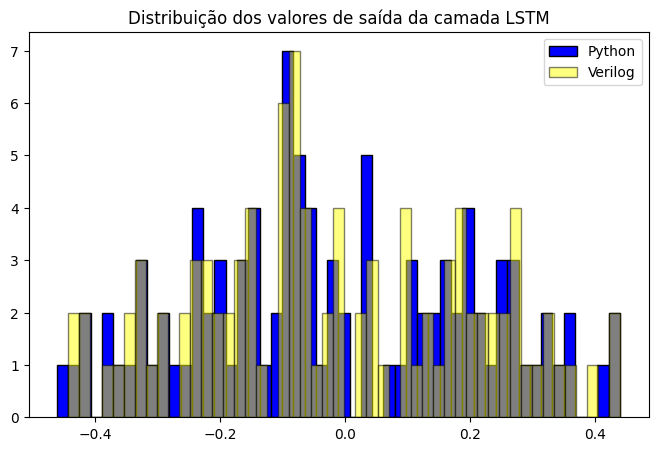

In [42]:
plt.figure(figsize=(8,5))

plt.hist(
    valores_out_lstm,
    bins=50,
    color=(0, 0, 1),
    alpha=1,
    edgecolor='black',
    label='Python'
)

plt.hist(
    out_verilog,
    bins=50,
    color='yellow',
    alpha=0.5,
    edgecolor='black',
    label='Verilog'
)

plt.title("Distribuição dos valores de saída da camada LSTM")
plt.legend()
plt.show()

R² = 0.998864


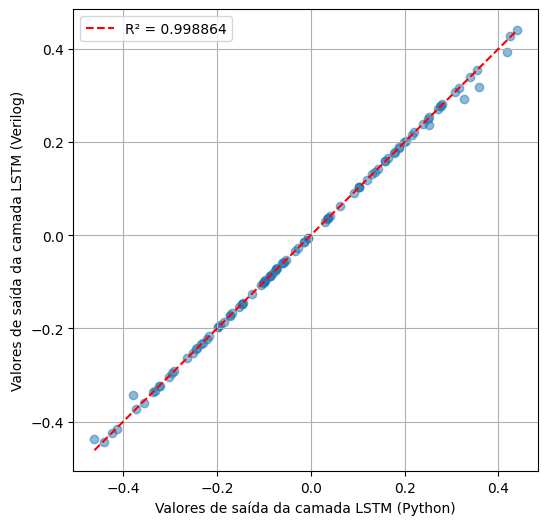

In [43]:

from sklearn.metrics import r2_score

plt.figure(figsize=(6,6))

plt.scatter(valores_out_lstm, out_verilog, alpha=0.5)

# reta y = x
lim_min = min(np.min(valores_out_lstm), np.min(out_verilog))
lim_max = max(np.max(valores_out_lstm), np.max(out_verilog))
r2 = r2_score(valores_out_lstm, out_verilog)
print(f"R² = {r2:.6f}")
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label=f'R² = {r2:.6f}')

# R²


plt.xlabel("Valores de saída da camada LSTM (Python)")
plt.ylabel("Valores de saída da camada LSTM (Verilog)")
plt.legend()
plt.grid(True)
plt.show()

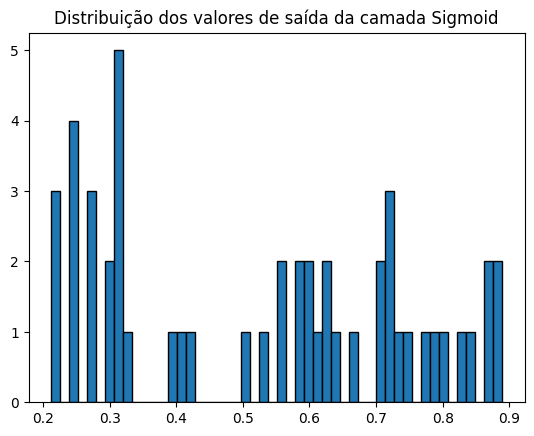

In [31]:
plt.title("Distribuição dos valores de saída da camada Sigmoid")
plt.hist(valores_out_sigmoid, bins=50, edgecolor='black')
plt.show()

In [32]:
dado = pd.read()

AttributeError: module 'pandas' has no attribute 'read'

In [ ]:
import numpy as np

# ============================================================
# CONSTANTES Q8.24
# ============================================================
FRAC = 24
SCALE = 1 << FRAC  # 2^24 = 16777216

def q24_to_float(q_val):
    """Converte Q8.24 para float32"""
    # Se for negativo (bit 31 = 1), faz o sinal
    if q_val >= 0x80000000:
        q_val = q_val - 0x100000000
    return q_val / SCALE

# ============================================================
# LEITURA SIMPLES DOS ARQUIVOS
# ============================================================
for i in range(1):
    arquivo = f"../../../Geral Tests SystemVerilog/Q8_24/Simplest Neural Network/Small Global Processing/dados_{i}.mem"
    
    try:
        with open(arquivo, "r") as f:
            linhas = f.readlines()
        
        # Pula linhas vazias
        linhas = [l.strip() for l in linhas if l.strip()]
        
        print(f"\nArquivo {i}: {len(linhas)} linhas")
        
        # Primeira linha (especial)
        primeira = linhas[0].split()
        if len(primeira) >= 4:
            addr = int(primeira[0], 16)
            data = int(primeira[1], 16)
            python_result = int(primeira[2], 16)
            gt = int(primeira[3], 16)
            
            print(f"  Python result: {q24_to_float(python_result):.6f}")
            print(f"  Ground truth: {gt}")
            print(f"  Primeiro dado: addr=0x{addr:05X}, data={q24_to_float(data):.6f}")
        
        # Mostra os primeiros 5 dados normais
        print(f"  Primeiros dados (Q8.24 -> float):")
        for j in range(1, min(6, len(linhas))):
            partes = linhas[j].split()
            if len(partes) >= 2:
                addr = int(partes[0], 16)
                data = int(partes[1], 16)
                print(f"    [{j}] addr=0x{addr:05X}, data={q24_to_float(data):.6f}")
        
    except FileNotFoundError:
        print(f"Arquivo {i} não encontrado")
        break
    except Exception as e:
        print(f"Erro no arquivo {i}: {e}")


Arquivo 0: 20 linhas
  Python result: 0.373072
  Ground truth: 1
  Primeiro dado: addr=0x00000, data=0.182690
  Primeiros dados (Q8.24 -> float):
    [1] addr=0x00001, data=0.155404
    [2] addr=0x00002, data=0.205526
    [3] addr=0x00003, data=-0.149686
    [4] addr=0x00004, data=0.143018
    [5] addr=0x00005, data=0.194240
